<a href="https://colab.research.google.com/github/MamidiPravallikaReddy/DL_LAB/blob/main/DL_week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2919 - val_loss: 0.2600
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2464 - val_loss: 0.2299
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2138 - val_loss: 0.1991
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1896 - val_loss: 0.1789
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1718 - val_loss: 0.1633
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1582 - val_loss: 0.1514
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1477 - val_loss: 0.1422
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1394 - val_loss: 0.1346
Epoch 9/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1325 - val_loss: 0.1282
Epoch 10/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1266 - val_loss: 0.1228
Epoch 11/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1217 - val_loss: 0.1183
Epoch 12/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

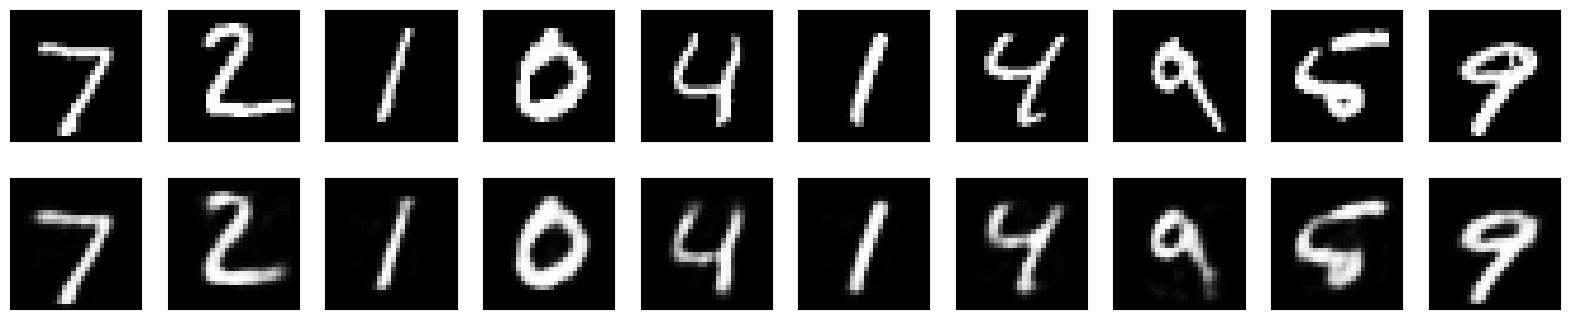

Mean Squared Error (MSE) on test set: 0.00771
Approximate pixel-level accuracy: 90.03%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

input_dim = 784
encoding_dim = 80

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=30, batch_size=200, shuffle=True, validation_data=(x_test, x_test))


decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

Epoch 1/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2951 - val_loss: 0.2644
Epoch 2/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2639 - val_loss: 0.2631
Epoch 3/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2633 - val_loss: 0.2629
Epoch 4/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2611 - val_loss: 0.2552
Epoch 5/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2503 - val_loss: 0.2452
Epoch 6/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2410 - val_loss: 0.2333
Epoch 7/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2233 - val_loss: 0.2134
Epoch 8/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2082 - val_loss: 0.2025
Epoch 9/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1997 - val_loss: 0.1955
Epoch 10/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1938 - val_loss: 0.1899
Epoch 11/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1877 - val_loss: 0.1840
Epoch 12/80
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

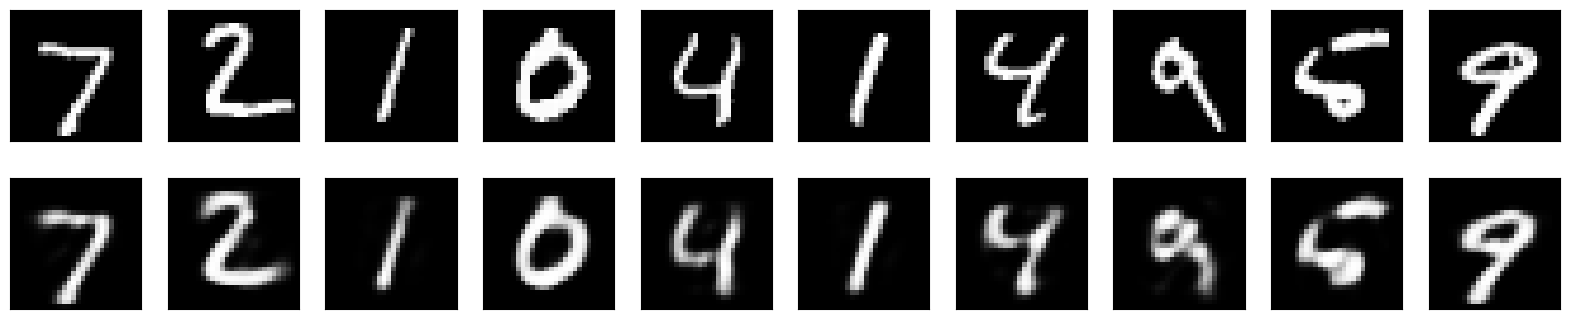

Mean Squared Error (MSE) on test set: 0.01147
Approximate pixel-level accuracy: 87.93%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

input_dim = 784
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=80, batch_size=100, shuffle=True, validation_data=(x_test, x_test))


decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

Epoch 1/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.2665 - val_loss: 0.2446
Epoch 2/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.2183 - val_loss: 0.1999
Epoch 3/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1928 - val_loss: 0.1853
Epoch 4/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.1810 - val_loss: 0.1764
Epoch 5/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1755 - val_loss: 0.1726
Epoch 6/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1728 - val_loss: 0.1706
Epoch 7/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1705 - val_loss: 0.1669
Epoch 8/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1664 - val_loss: 0.1628
Epoch 9/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1620 - val_loss: 0.1592
Epoch 10/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1597 - val_loss: 0.1571
Epoch 11/30
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1544 - val_loss: 0.1491
Epoch 12/30
3000/3000 ━━━━━━━

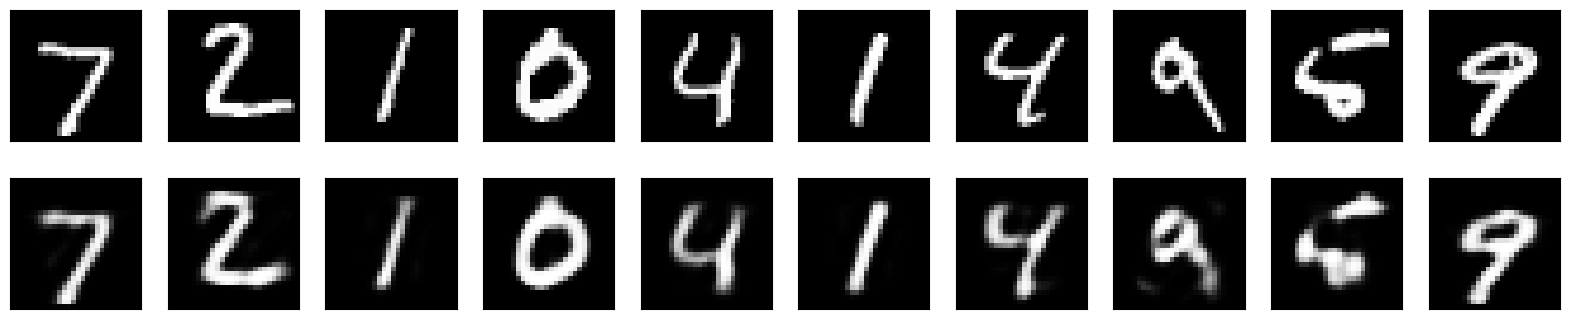

Mean Squared Error (MSE) on test set: 0.01075
Approximate pixel-level accuracy: 88.75%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

input_dim = 784
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=30, batch_size=20, shuffle=True, validation_data=(x_test, x_test))

decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1885 - val_loss: 0.1268
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1094 - val_loss: 0.0950
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0892 - val_loss: 0.0829
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0805 - val_loss: 0.0769
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0758 - val_loss: 0.0735
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0729 - val_loss: 0.0713
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0710 - val_loss: 0.0698
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0697 - val_loss: 0.0687
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0687 - val_loss: 0.0679
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0679 - val_loss: 0.0673
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0673 - val_loss: 0.0668
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

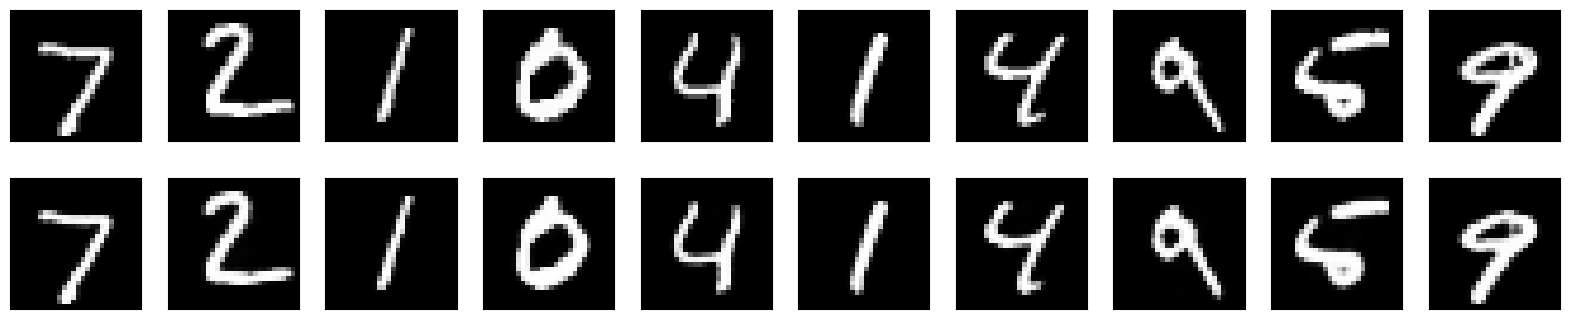

Mean Squared Error (MSE) on test set: 0.00114
Approximate pixel-level accuracy: 97.02%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

input_dim = 784
encoding_dim = 800

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=30, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1378 - val_loss: 0.0812
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0749 - val_loss: 0.0702
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0689 - val_loss: 0.0673
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0670 - val_loss: 0.0661
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0660 - val_loss: 0.0653
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0654 - val_loss: 0.0649
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0649 - val_loss: 0.0646
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0646 - val_loss: 0.0644
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0644 - val_loss: 0.0641
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0642 - val_loss: 0.0640
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0641 - val_loss: 0.0639
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

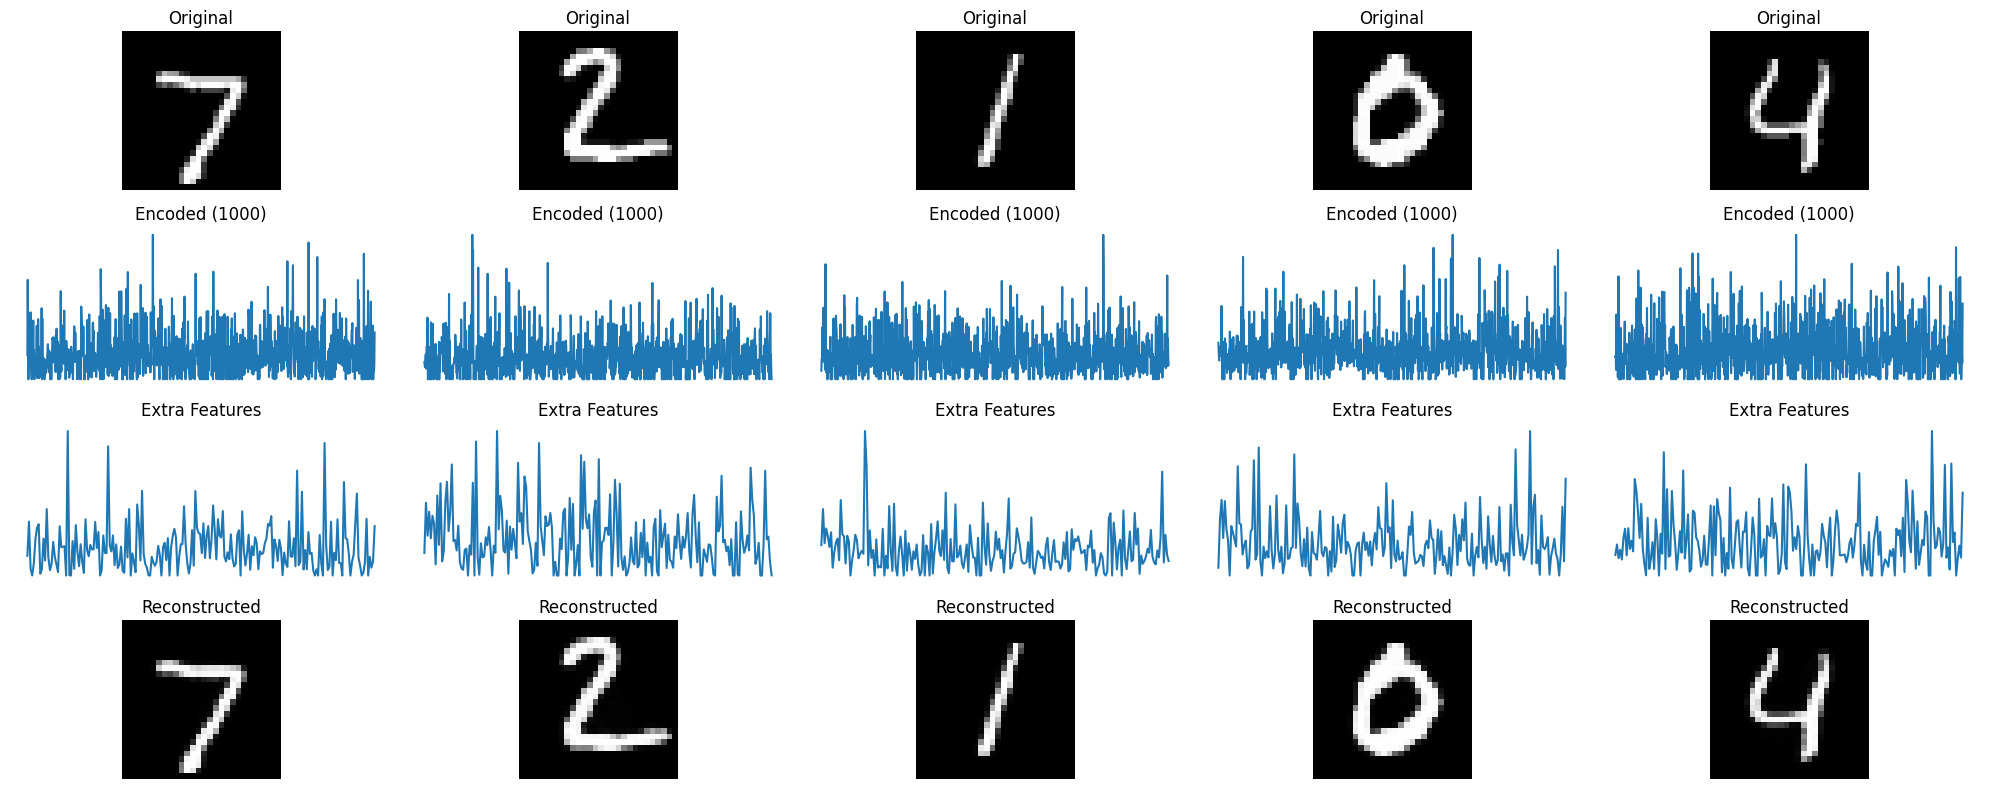

Mean Squared Error (MSE): 0.00081
Approximate Pixel Accuracy: 97.67%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

input_dim = 784
encoding_dim = 1000

input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim, activation='relu')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

encoder = Model(input_layer, encoded)

encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(
    x_train, x_train,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

n = 5
plt.figure(figsize=(20, 8))

for i in range(n):

    ax = plt.subplot(4, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.axis('off')

    ax = plt.subplot(4, n, i + 1 + n)
    plt.plot(encoded_imgs[i])
    plt.title("Encoded (1000)")
    ax.axis('off')

    ax = plt.subplot(4, n, i + 1 + 2*n)
    extra_part = encoded_imgs[i][784:]
    plt.plot(extra_part)
    plt.title("Extra Features")
    ax.axis('off')

    ax = plt.subplot(4, n, i + 1 + 3*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE): {mse:.5f}")

accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate Pixel Accuracy: {accuracy*100:.2f}%")

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1790 - val_loss: 0.1263
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1197 - val_loss: 0.1141
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1123 - val_loss: 0.1103
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1090 - val_loss: 0.1082
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1068 - val_loss: 0.1066
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1050 - val_loss: 0.1054
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1035 - val_loss: 0.1046
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1022 - val_loss: 0.1038
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1011 - val_loss: 0.1031
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1000 - val_loss: 0.1026
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0992 - val_loss: 0.1023
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

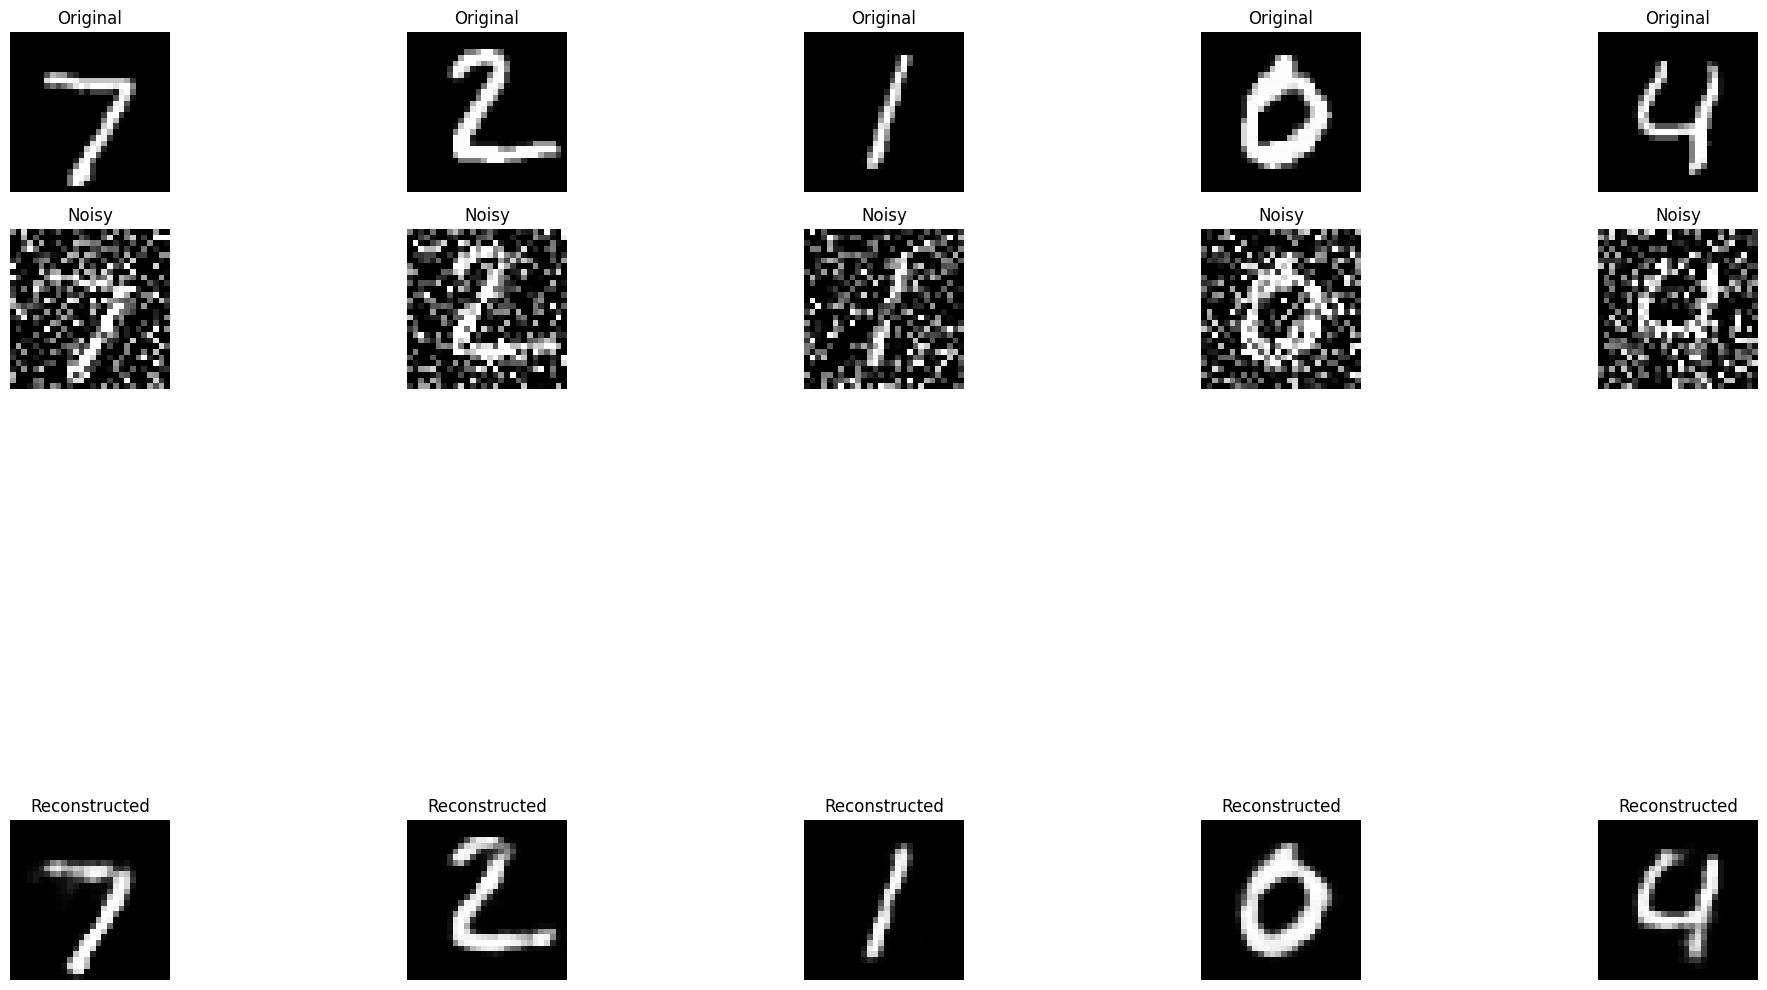

Mean Squared Error (MSE): 0.01256
Approx Pixel Accuracy: 88.78%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

input_dim = 784
encoding_dim = 1000

input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim, activation='relu')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

encoder = Model(input_layer, encoded)

encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(
    x_train_noisy, x_train,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

encoded_imgs = encoder.predict(x_test_noisy)
decoded_imgs = decoder.predict(encoded_imgs)

n = 5
plt.figure(figsize=(20, 10))

for i in range(n):

    ax = plt.subplot(5, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.axis('off')

    ax = plt.subplot(5, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.title("Noisy")
    plt.gray()
    ax.axis('off')

    ax = plt.subplot(5, n, i + 1 + 4*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE): {mse:.5f}")

accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approx Pixel Accuracy: {accuracy*100:.2f}%")

--2026-04-14 07:26:46--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat.4’

train_32x32.mat.4   100%[===================>] 173.61M  51.6MB/s    in 3.9s    

2026-04-14 07:26:50 (44.0 MB/s) - ‘train_32x32.mat.4’ saved [182040794/182040794]

--2026-04-14 07:26:50--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat.4’

test_32x32.mat.4    100%[===================>]  61.30M  14.8MB/s    in 4.2s    

2026-04-14 07:26:55 (14.7 MB/s) - ‘test_32x32.mat.4’ saved [642

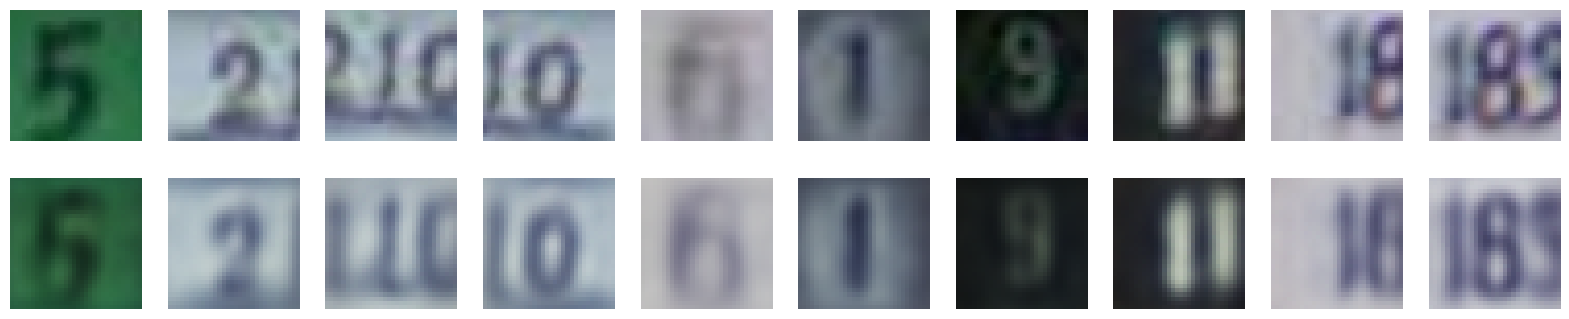

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Mean Squared Error (MSE): 0.00325
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Approx Pixel Accuracy: 91.93%


In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

train = scipy.io.loadmat('train_32x32.mat')
test = scipy.io.loadmat('test_32x32.mat')

x_train = np.transpose(train['X'], (3,0,1,2))
x_test = np.transpose(test['X'], (3,0,1,2))

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 32*32*3))
x_test = x_test.reshape((len(x_test), 32*32*3))

input_dim = 3072
encoding_dim = 256

input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(
    x_train[:30000], x_train[:30000],
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test[:5000], x_test[:5000])
)

decoded_imgs = autoencoder.predict(x_test[:10])

n = 10
plt.figure(figsize=(20,4))

for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(32,32,3))
    plt.axis('off')

plt.show()

mse = np.mean(np.square(x_test[:5000] - autoencoder.predict(x_test[:5000])))
print(f"Mean Squared Error (MSE): {mse:.5f}")

accuracy = np.mean(np.abs(x_test[:5000] - autoencoder.predict(x_test[:5000])) < 0.1)
print(f"Approx Pixel Accuracy: {accuracy*100:.2f}%")

--2026-04-14 07:19:39--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat.3’

train_32x32.mat.3   100%[===================>] 173.61M  7.84MB/s    in 14s     

2026-04-14 07:19:53 (12.8 MB/s) - ‘train_32x32.mat.3’ saved [182040794/182040794]

--2026-04-14 07:19:53--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat.3’

test_32x32.mat.3    100%[===================>]  61.30M  31.2MB/s    in 2.0s    

2026-04-14 07:19:55 (31.2 MB/s) - ‘test_32x32.mat.3’ saved [642

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


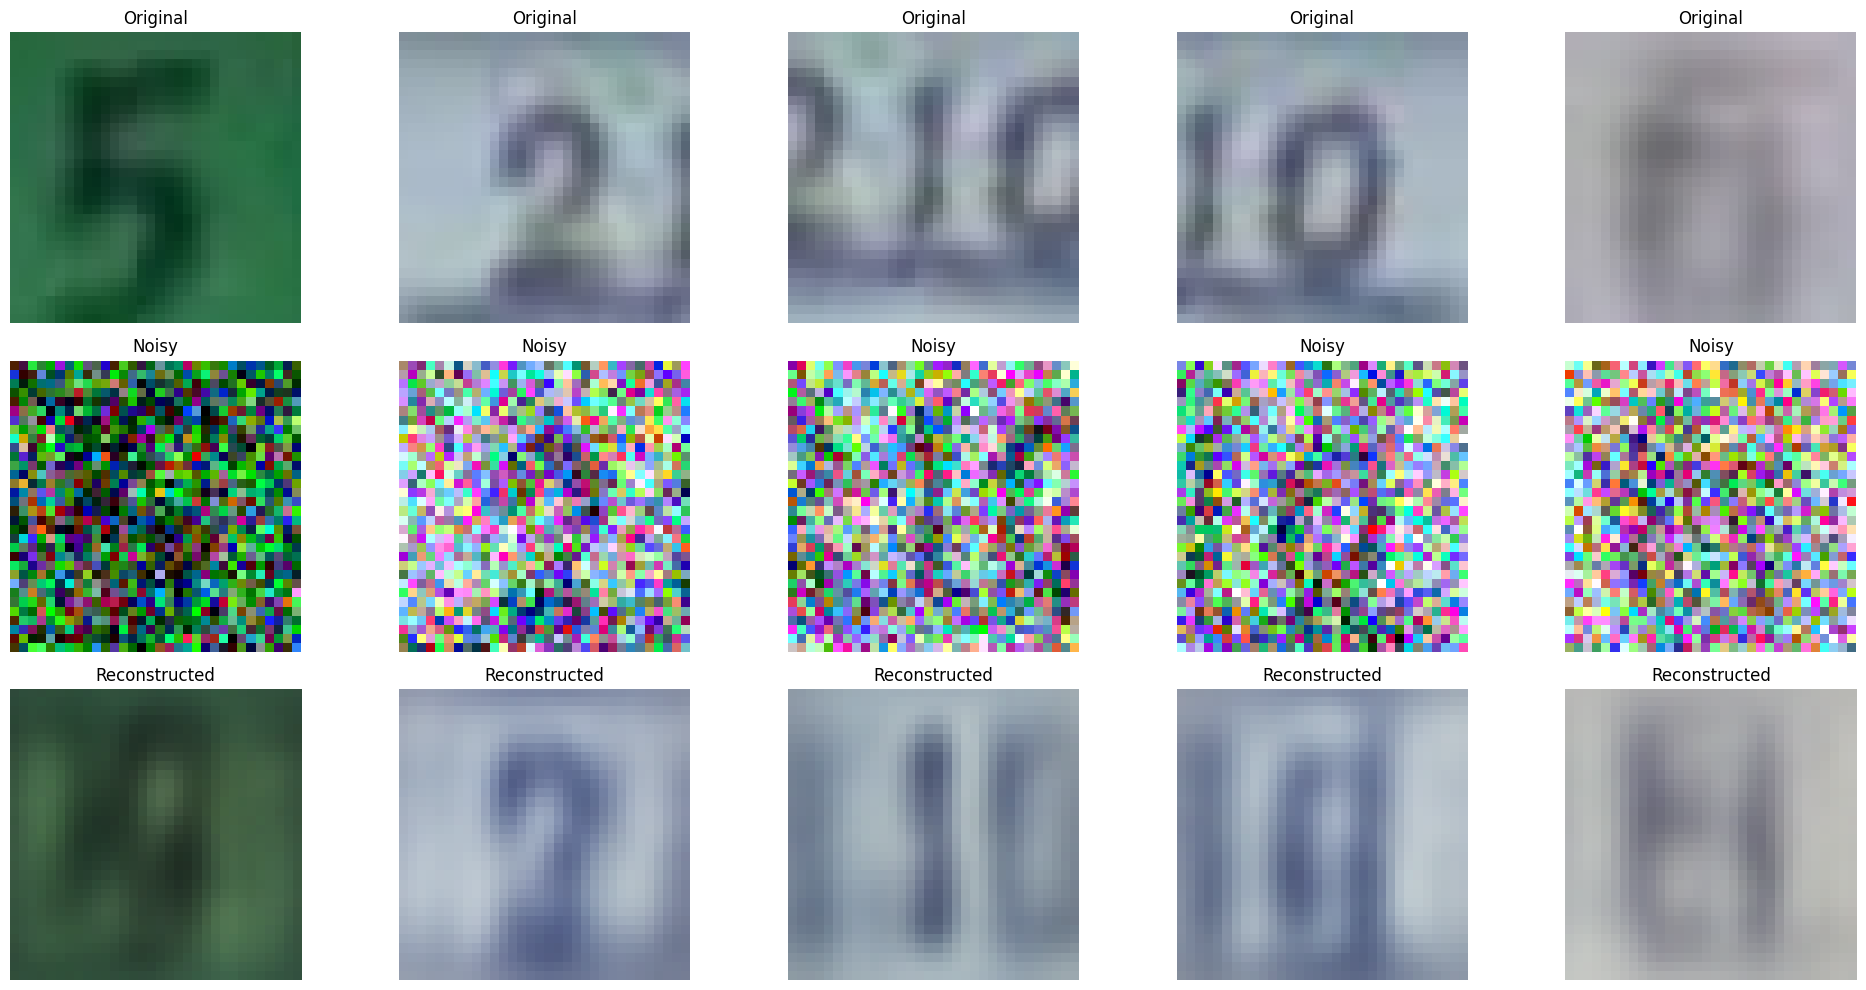

Mean Squared Error (MSE): 0.00529
Approx Pixel Accuracy: 86.13%


In [ ]:
import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

train = scipy.io.loadmat('train_32x32.mat')
test = scipy.io.loadmat('test_32x32.mat')

x_train = np.transpose(train['X'], (3,0,1,2))
x_test = np.transpose(test['X'], (3,0,1,2))


x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 3072))
x_test = x_test.reshape((len(x_test), 3072))

noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

input_dim = 3072
encoding_dim = 512

input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim, activation='relu')(input_layer)
encoded = Dense(256, activation='relu')(encoded)

decoded = Dense(512, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

encoder = Model(input_layer, encoded)

encoded_input = Input(shape=(256,))
decoder_layer1 = autoencoder.layers[-2]
decoder_layer2 = autoencoder.layers[-1]

decoder = Model(encoded_input, decoder_layer2(decoder_layer1(encoded_input)))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(
    x_train_noisy[:30000], x_train[:30000],
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy[:5000], x_test[:5000])
)

encoded_imgs = encoder.predict(x_test_noisy[:5000])
decoded_imgs = decoder.predict(encoded_imgs)

n = 5
plt.figure(figsize=(20,10))

for i in range(n):

    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(32,32,3))
    plt.title("Noisy")
    plt.gray()
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(32,32,3))
    plt.title("Reconstructed")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

mse = np.mean(np.square(x_test[:5000] - decoded_imgs))
print(f"Mean Squared Error (MSE): {mse:.5f}")

accuracy = np.mean(np.abs(x_test[:5000] - decoded_imgs) < 0.1)
print(f"Approx Pixel Accuracy: {accuracy*100:.2f}%")

--2026-04-14 07:28:08--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat.5’

train_32x32.mat.5   100%[===================>] 173.61M  11.7MB/s    in 7.9s    

2026-04-14 07:28:17 (21.8 MB/s) - ‘train_32x32.mat.5’ saved [182040794/182040794]

--2026-04-14 07:28:17--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat.5’

test_32x32.mat.5    100%[===================>]  61.30M  22.3MB/s    in 2.8s    

2026-04-14 07:28:19 (22.3 MB/s) - ‘test_32x32.mat.5’ saved [642

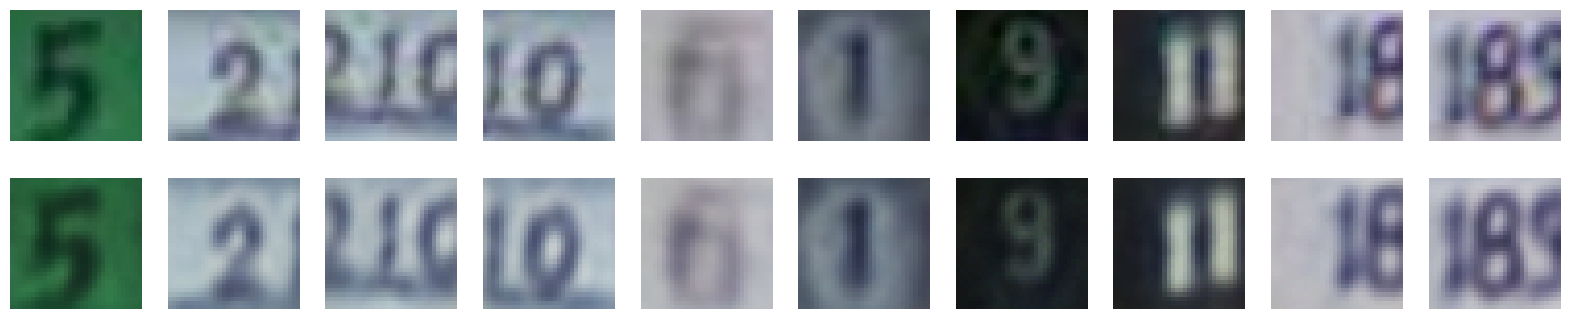

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Mean Squared Error (MSE): 0.00183
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Approx Pixel Accuracy: 95.77%


In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

train = scipy.io.loadmat('train_32x32.mat')
test = scipy.io.loadmat('test_32x32.mat')

x_train = np.transpose(train['X'], (3,0,1,2))
x_test = np.transpose(test['X'], (3,0,1,2))

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 32*32*3))
x_test = x_test.reshape((len(x_test), 32*32*3))

input_dim = 3072
encoding_dim = 4000

input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(
    x_train[:30000], x_train[:30000],
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test[:5000], x_test[:5000])
)

decoded_imgs = autoencoder.predict(x_test[:10])

n = 10
plt.figure(figsize=(20,4))

for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(32,32,3))
    plt.axis('off')

plt.show()

mse = np.mean(np.square(x_test[:5000] - autoencoder.predict(x_test[:5000])))
print(f"Mean Squared Error (MSE): {mse:.5f}")

accuracy = np.mean(np.abs(x_test[:5000] - autoencoder.predict(x_test[:5000])) < 0.1)
print(f"Approx Pixel Accuracy: {accuracy*100:.2f}%")